<a href="https://colab.research.google.com/github/vignytl1-oss/data-analytics-portfolio/blob/main/Airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United St

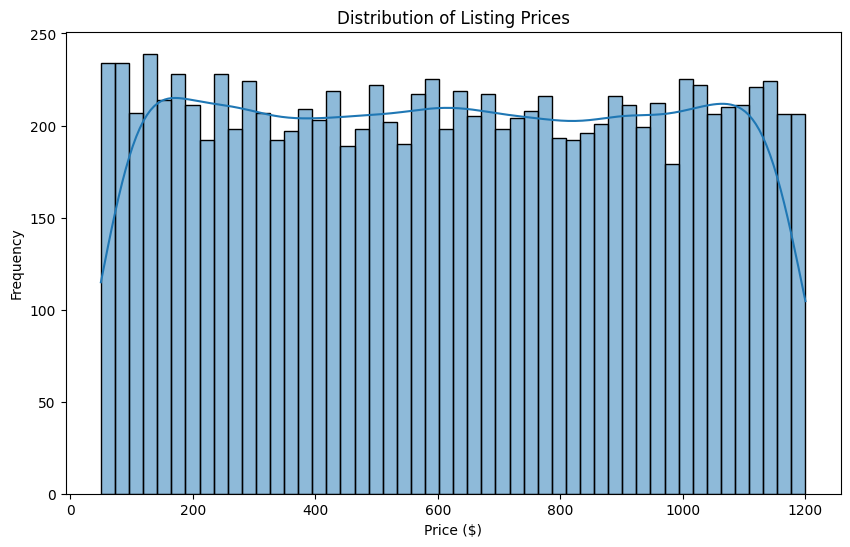

Unique values in 'room type' column before cleaning:
['Private room' 'Entire home/apt' 'Shared room']


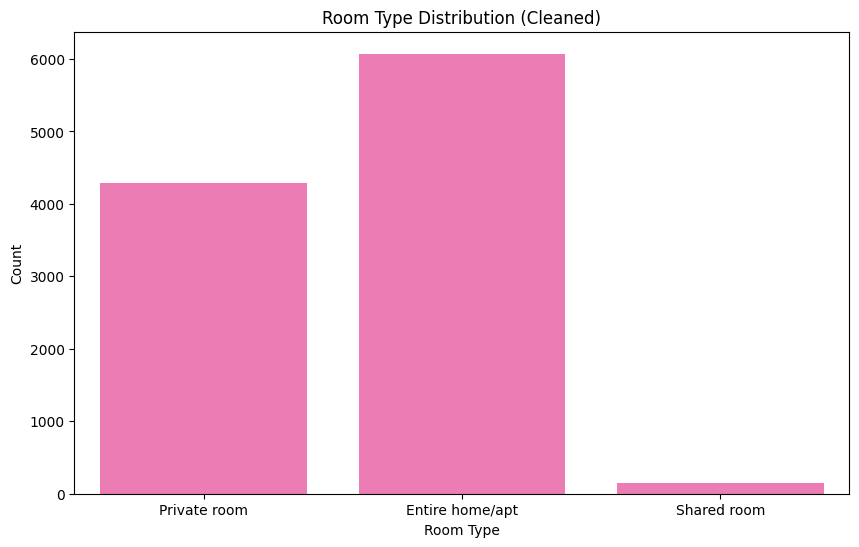

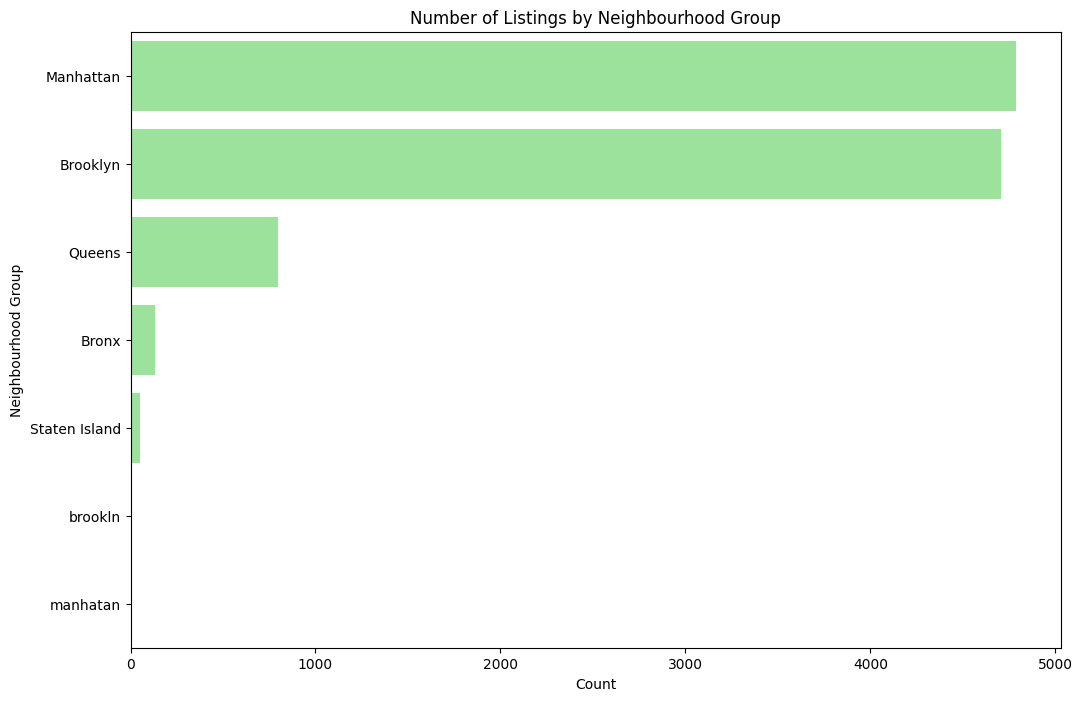

/tmp/ipykernel_1855/2169900358.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Room Type')


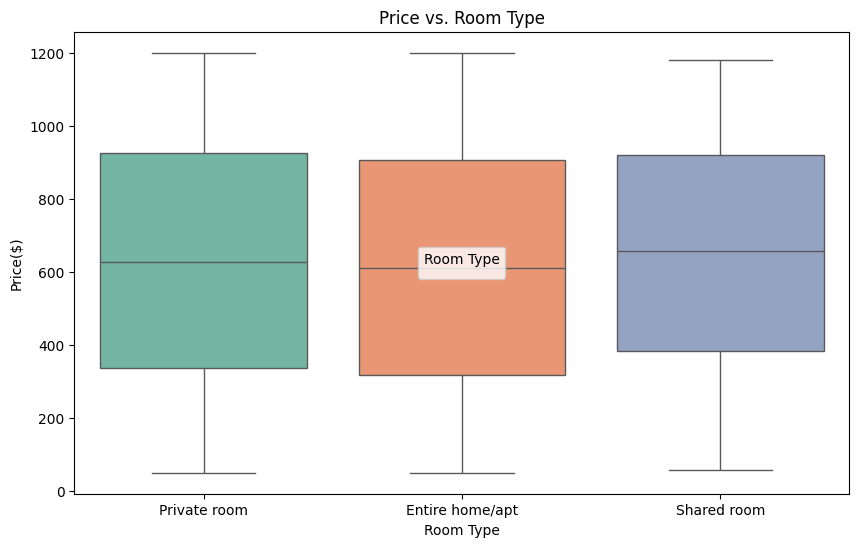

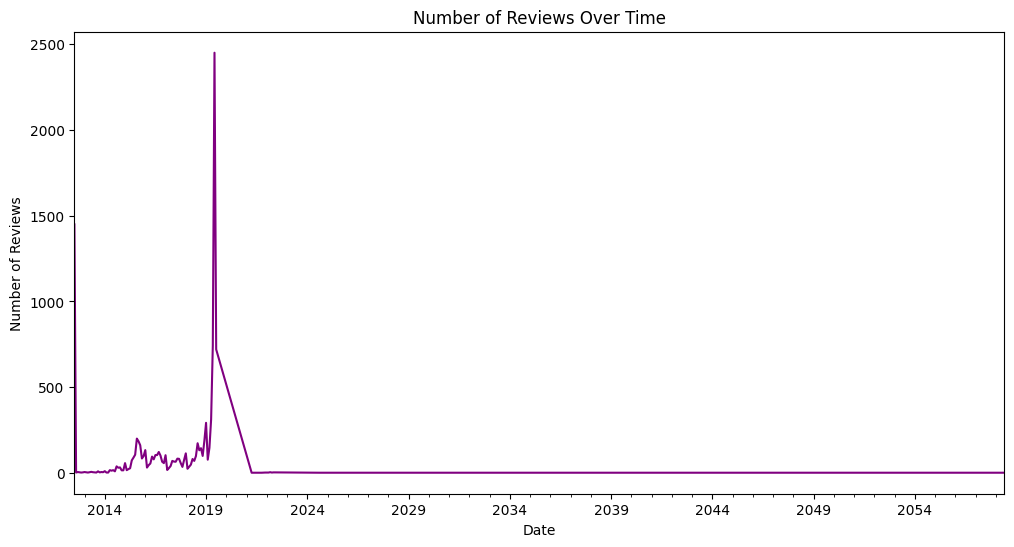

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "/content/Airbnb_Open_Data.csv"
df = pd.read_csv(file_path, on_bad_lines='skip', engine='python')
print(df.head())
df.columns
print(df.isnull().sum())

# Convert 'last review' to datetime and have less errors
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

#Fill missing values
df.fillna({'reviews per month': 0, 'last review': df['last review'].min()}, inplace=True)

# Drop records with missing 'name' or 'host name'
df.dropna(subset=['NAME', 'host name'], inplace=True)

# Remove dollar signs and convert to float
df['price'] = df['price'].str.replace('[$,]', '', regex= True).astype(float)
df['service fee'] = pd.to_numeric(df['service fee'].str.replace('[$,]', '', regex= True), errors='coerce')

df.drop_duplicates(inplace=True)

print(df.info())
print(df.describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Listing Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# --- Room Type Analysis ---

# First, inspect unique values in 'room type' to identify anomalies
print("Unique values in 'room type' column before cleaning:")
print(df['room type'].unique())

# Define valid room types
valid_room_types = ['Private room', 'Entire home/apt', 'Shared room']

# Filter out invalid room types
df_filtered_room_type = df[df['room type'].isin(valid_room_types)]

plt.figure(figsize=(10,6)) # Increased figure width
sns.countplot(x='room type', data=df_filtered_room_type, color='hotpink')
plt.title('Room Type Distribution (Cleaned)')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

# Neighbourhoud Analysis.
plt.figure(figsize=(12, 8))
sns.countplot(y='neighbourhood group', data=df, color='lightgreen', order=df['neighbourhood group'].value_counts().index)
plt.title('Number of Listings by Neighbourhood Group')
plt.xlabel('Count')
plt.ylabel('Neighbourhood Group')
plt.show()

# Price vs Room Type
plt.figure(figsize=(10,6))
sns.boxplot(x='room type', y='price', hue='room type', data=df, palette='Set2')
plt.title('Price vs. Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price($)')
plt.legend(title='Room Type')
plt.show()

# Reviews Over Time
df['last review']= pd.to_datetime(df['last review'])
reviews_over_time = df.groupby(df['last review'].dt.to_period('M')).size()

plt.figure(figsize=(12,6))
reviews_over_time.plot(kind='line', color='purple')
plt.title('Number of Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()
